In [58]:
import torch
from torchvision.datasets import FashionMNIST
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

In [28]:
transform = transforms.ToTensor()

In [29]:
train_dataset = FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = FashionMNIST(root='./data', train=False, download=True, transform=transform)

In [30]:
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=True)

In [31]:
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(in_features=32*7*7, out_features=10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.linear(x)
        return x

In [32]:
model = FashionCNN()
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

In [33]:
# dummy_input = torch.randn(1, 1, 28, 28)

# torch.onnx.export(model, dummy_input, "fashion_cnn.onnx")

<img src="scheme.png">

In [ ]:
epochs = 15
classes = ['Футболка', 'Штаны', 'Свитер', 'Платье', 'Пальто',
           'Сандалии', 'Рубашка', 'Кроссовки', 'Сумка', 'Ботинки']


for epoch in range(epochs):
    
    model.train()
    for images, labels in train_dataloader:
        optimizer.zero_grad()
        predict = model(images)
        Loss = criterion(predict, labels)
        Loss.backward()
        optimizer.step()

    model.eval()

    test_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for images, labels in test_dataloader:
                predict = model(images)
                predicted_classes = torch.argmax(predict, dim=1)
                Loss = criterion(predict, labels)
                test_loss += Loss.item()
                correct_predictions += (predicted_classes == labels).sum().item()
                total_predictions += len(labels)

    avg_test_loss = test_loss / len(test_dataloader)
    accuracy = (correct_predictions / total_predictions) * 100
    print(f'Эпоха [{epoch+1}/{epochs}], Loss на тесте: {avg_test_loss:.4f}, Точность: {accuracy:.2f}%')


Эпоха [1/15], Loss на тесте: 0.3413, Точность: 87.63%
Эпоха [2/15], Loss на тесте: 0.3270, Точность: 88.39%
Эпоха [3/15], Loss на тесте: 0.3328, Точность: 88.50%
Эпоха [4/15], Loss на тесте: 0.3183, Точность: 88.37%
Эпоха [5/15], Loss на тесте: 0.3237, Точность: 88.36%
Эпоха [6/15], Loss на тесте: 0.3217, Точность: 88.82%
Эпоха [7/15], Loss на тесте: 0.3132, Точность: 88.80%
Эпоха [8/15], Loss на тесте: 0.3437, Точность: 88.06%
Эпоха [9/15], Loss на тесте: 0.3286, Точность: 88.68%
Эпоха [10/15], Loss на тесте: 0.3211, Точность: 88.60%
Эпоха [11/15], Loss на тесте: 0.3214, Точность: 88.93%
Эпоха [12/15], Loss на тесте: 0.3335, Точность: 88.11%
Эпоха [13/15], Loss на тесте: 0.3339, Точность: 88.82%
Эпоха [14/15], Loss на тесте: 0.3421, Точность: 88.68%
Эпоха [15/15], Loss на тесте: 0.3526, Точность: 88.00%


In [ ]:
def printCycle(single_image, true_label):
    model.eval()
    with torch.no_grad():
        img_display = single_image.squeeze().numpy()
        
        out_conv1 = model.conv1(single_image)
        out_conv1 = model.relu(out_conv1)
        out_pool1 = model.pool(out_conv1)
        out_conv2 = model.conv2(out_pool1)
        out_conv2 = model.relu(out_conv2)
        out_pool2 = model.pool(out_conv2)
        out_flat = model.flatten(out_pool2)
        logits = model.linear(out_flat)
        
        probabilities = F.softmax(logits, dim=1).squeeze().numpy() * 100

    fig = plt.figure(figsize=(15, 10))

    ax_main = fig.add_subplot(3, 1, 1)
    ax_main.imshow(img_display, cmap='gray')
    ax_main.set_title(f"Входное изображение (Истинный класс: {classes[true_label]})", fontsize=14)
    ax_main.axis('off')

    features1 = out_pool1.cpu().squeeze().numpy()
    for i in range(8):
        ax = fig.add_subplot(3, 8, 8 + i + 1)
        ax.imshow(features1[i], cmap='viridis') 
        ax.axis('off')
        if i == 3: ax.set_title("Слой 1", fontsize=12)

    features2 = out_pool2.cpu().squeeze().numpy()
    for i in range(8):
        ax = fig.add_subplot(3, 8, 16 + i + 1)
        ax.imshow(features2[i], cmap='viridis')
        ax.axis('off')
        if i == 3: ax.set_title("Слой 2", fontsize=12)

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.bar(classes, probabilities, color='skyblue', edgecolor='black')
    plt.title("Уверенность нейросети по классам (%)", fontsize=14)
    plt.ylabel("Вероятность (%)")
    plt.ylim(0, 100)
    for i, v in enumerate(probabilities):
        if v > 1:
            plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')
    plt.show()

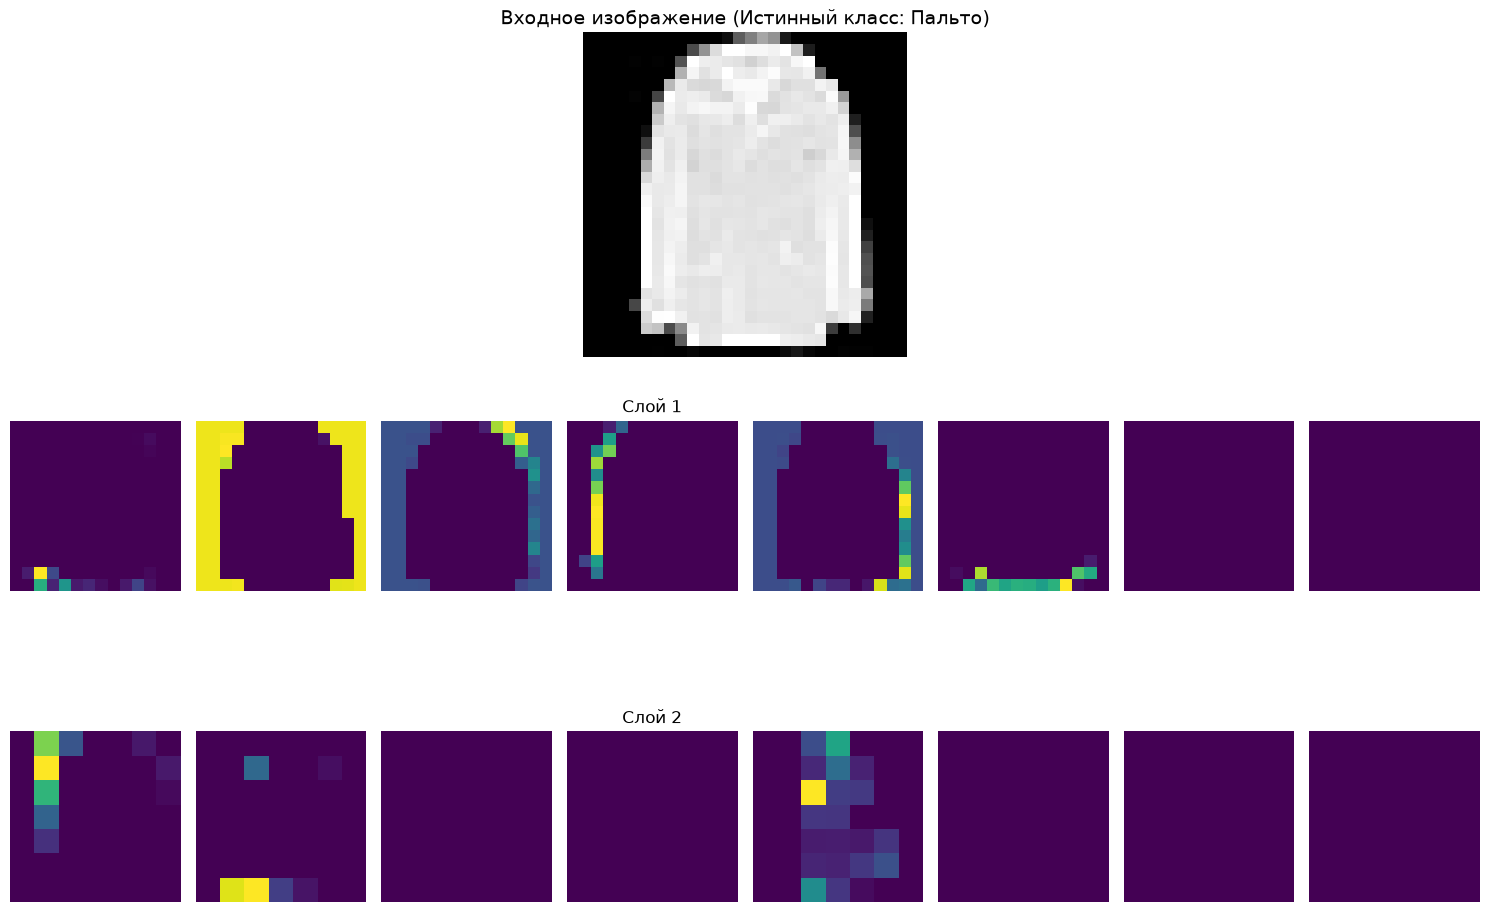

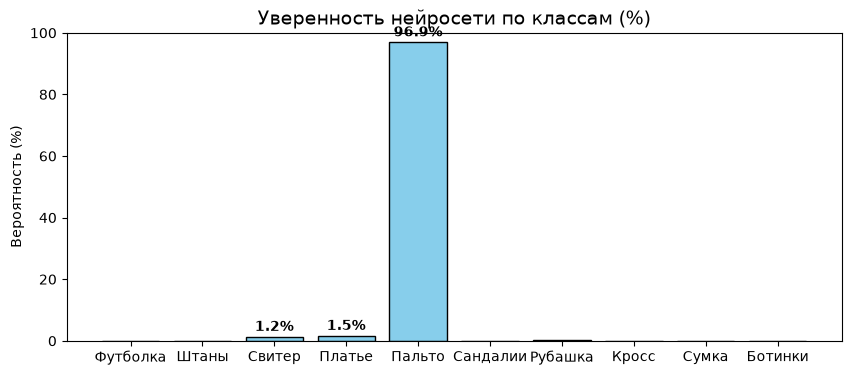

In [64]:
images, labels = next(iter(test_dataloader))
single_image = images[0].unsqueeze(0)
true_label = labels[0].item()
printCycle(single_image, true_label)

Проверим на настоящем фото

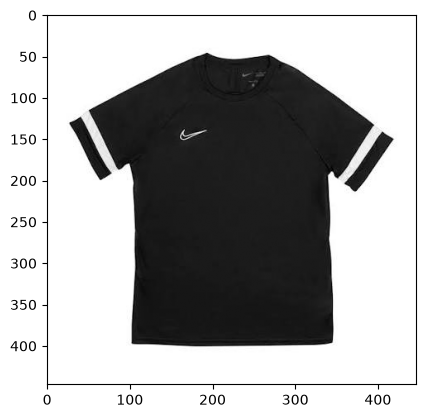

In [ ]:
import cv2 as cv

img = cv.imread('t_shirt.jpg', cv.IMREAD_GRAYSCALE)

plt.figure()
plt.imshow(img, cmap='gray')
plt.show()

In [50]:
print(img.shape)

(447, 447)


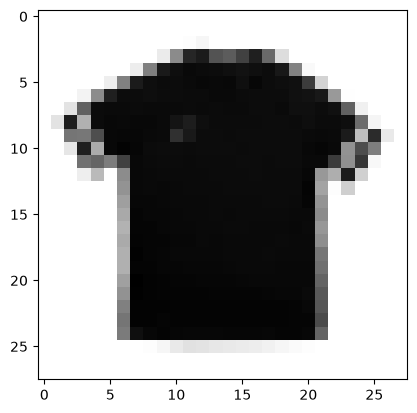

In [51]:
img_resized = cv.resize(img, (28,28), interpolation=cv.INTER_AREA)
plt.figure()
plt.imshow(img_resized, cmap='gray')
plt.show()

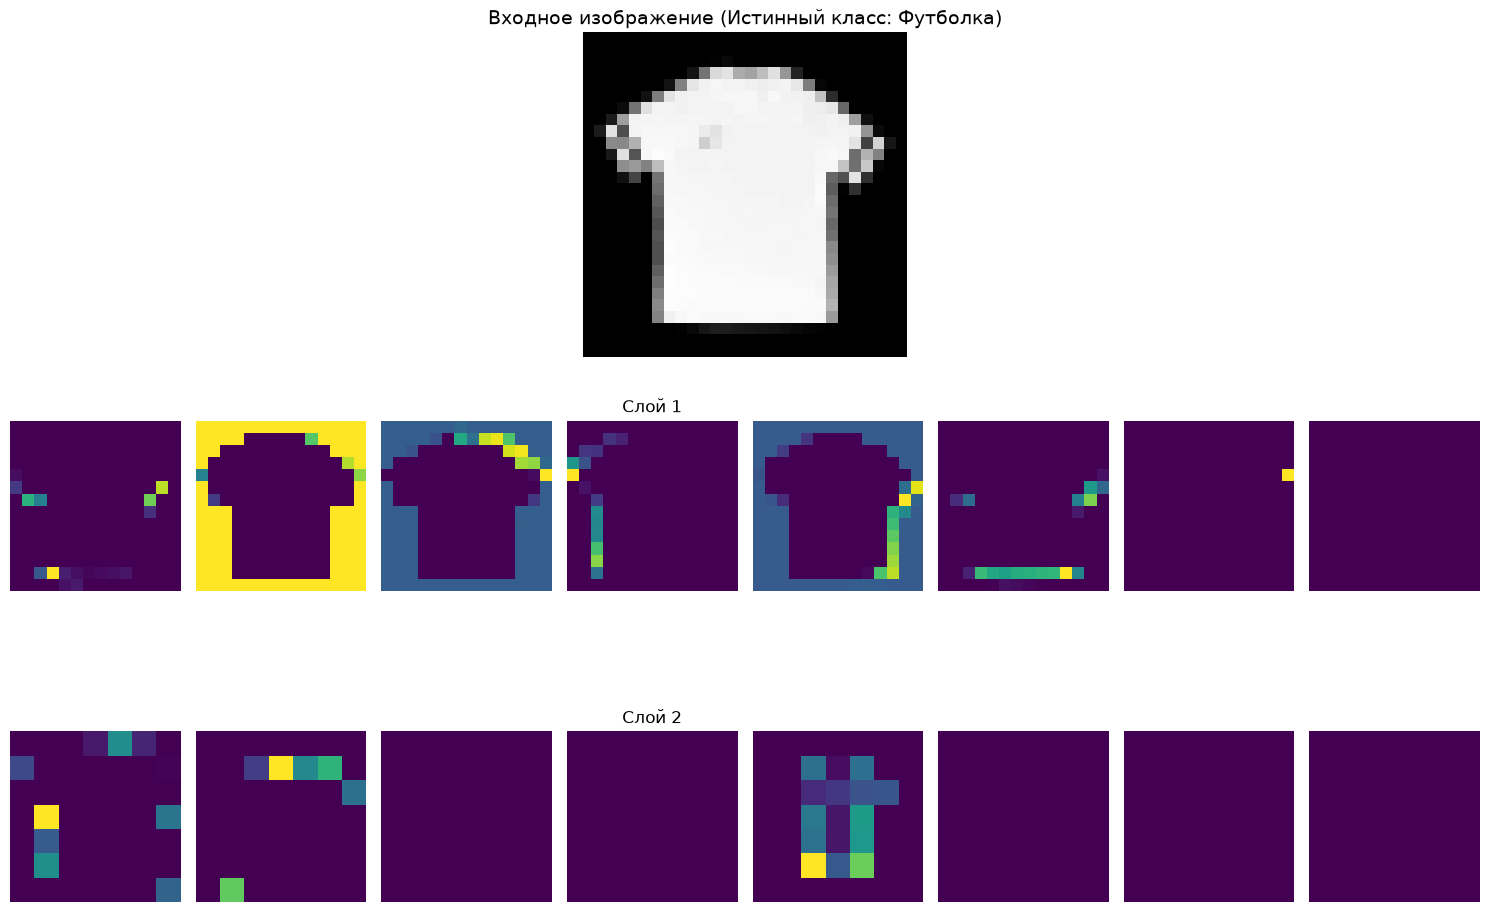

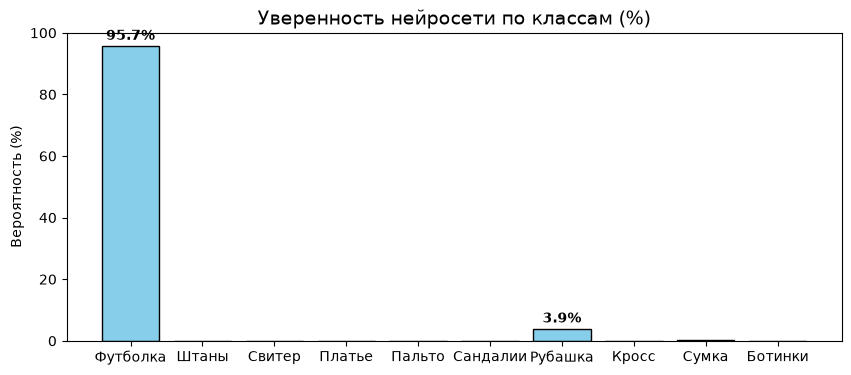

In [63]:
img_float = img_resized.astype(np.float32) / 255.0
img_inv = 1.0 - img_float
img_tensor = torch.from_numpy(img_inv)

img_tensor = img_tensor.unsqueeze(0).unsqueeze(0)
printCycle(img_tensor, 0)
